# **Task 3: Car Price Prediction with Machine Learning**

Objective

To build a machine learning regression model that predicts the price of a car based on its features such as brand, year, present price, kilometers driven, fuel type, seller type, transmission, and owner.

# **Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# **Load the Dataset**

In [2]:
from google.colab import files

uploaded = files.upload()

Saving car data.csv to car data.csv


# **Read the Dataset**

In [3]:
df = pd.read_csv('/content/car data.csv')

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


# **Dataset Information**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


# **Check Missing Values**

In [5]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


# **Dataset Description**

In [6]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


# **Selling Price Distribution**

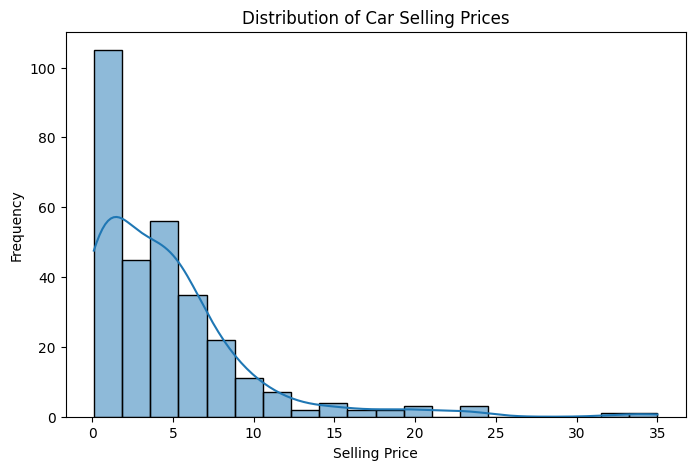

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Selling_Price'], bins=20, kde=True)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.show()

# **Present Price vs Selling Price**

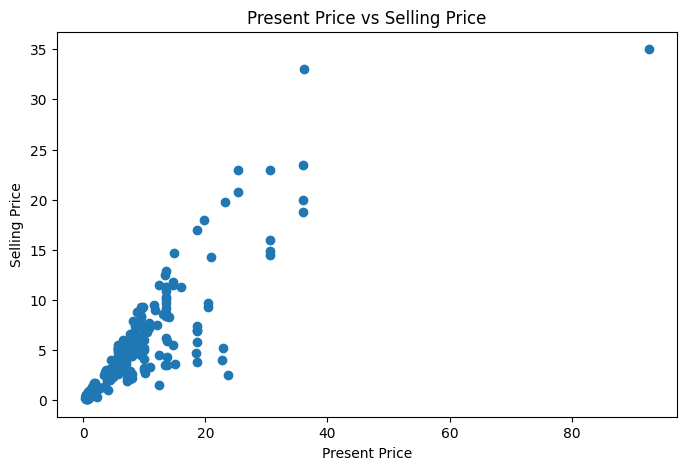

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Present_Price'], df['Selling_Price'])
plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.title("Present Price vs Selling Price")
plt.show()

# **Year vs Selling Price**

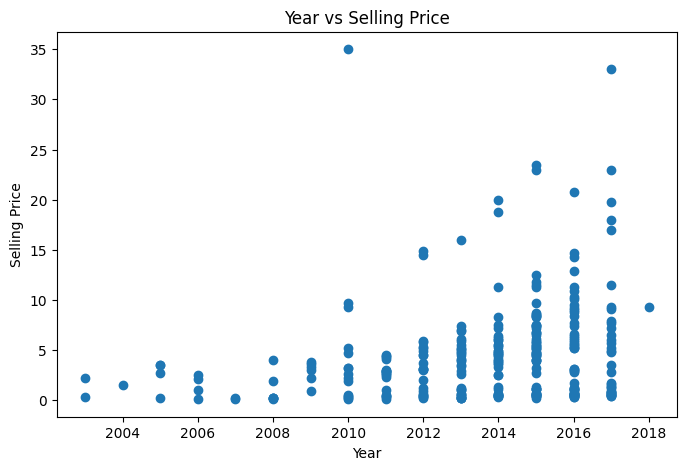

In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Year'], df['Selling_Price'])
plt.xlabel("Year")
plt.ylabel("Selling Price")
plt.title("Year vs Selling Price")
plt.show()

# **Driven Kilometers vs Selling Price**

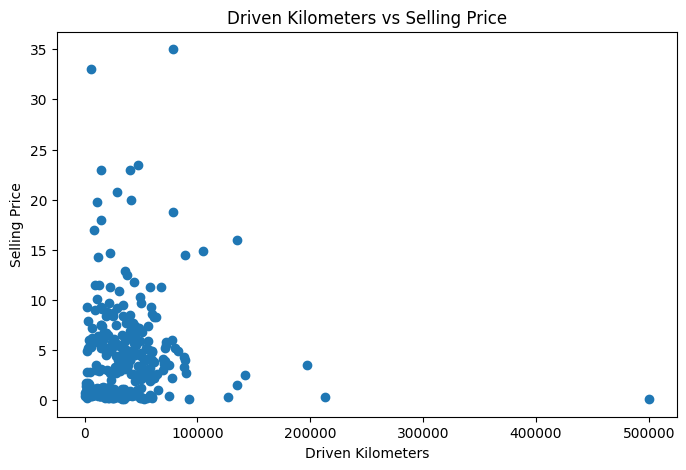

In [24]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Driven_kms'], df['Selling_Price'])
plt.xlabel("Driven Kilometers")
plt.ylabel("Selling Price")
plt.title("Driven Kilometers vs Selling Price")
plt.show()

# **Check Duplicate Records**

In [7]:
df.duplicated().sum()

np.int64(2)

# **Remove Duplicate Records**

In [8]:
df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

# **Feature Engineering: Car Age**

In [9]:
current_year = 2020

df['Car_Age'] = current_year - df['Year']

df[['Year', 'Car_Age']].head()

,Year,Car_Age
0,2014,6
1,2013,7
2,2017,3
3,2011,9
4,2014,6


# **Select Features and Target**

In [10]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X.head()

,Car_Name,Year,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,5.59,27000,Petrol,Dealer,Manual,0,6
1,sx4,2013,9.54,43000,Diesel,Dealer,Manual,0,7
2,ciaz,2017,9.85,6900,Petrol,Dealer,Manual,0,3
3,wagon r,2011,4.15,5200,Petrol,Dealer,Manual,0,9
4,swift,2014,6.87,42450,Diesel,Dealer,Manual,0,6


# **Identify Categorical and Numerical Features**

In [11]:
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(exclude=['object']).columns

print("Categorical Features:", list(categorical_features))
print("Numerical Features:", list(numerical_features))

Categorical Features: ['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']
Numerical Features: ['Year', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age']


# **Encode Categorical Features**

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# **Train-Test Split**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 239
Testing samples: 60


# **Build Regression Pipeline**

In [15]:
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)

# **Train the Regression Model**

In [16]:
model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission'], dtype='object'))])),
                ('regressor', LinearRegression())])

The Linear Regression model was successfully trained using the prepared training data.

# **Make Predictions**

In [17]:
y_pred = model.predict(X_test)

y_pred[:10]

array([ 8.11564809,  7.66877965,  1.41494353,  6.75105892,  9.83242748,
        5.04302648,  8.06091862,  2.34990153,  8.71053466, -1.46878584])

# **Evaluate the Regression Model**

In [18]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 1.411794734239386
Root Mean Squared Error: 2.431332564554182
R² Score: 0.7706391224947571


# **Actual vs Predicted Prices**

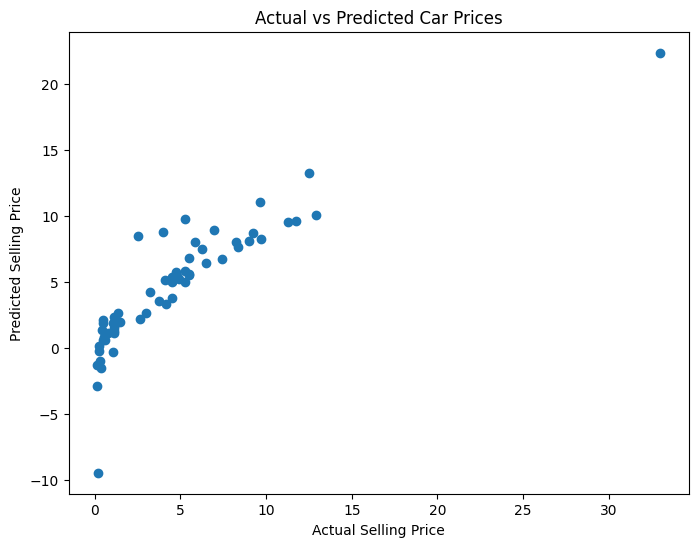

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

# **Feature Importance / Coefficient Analysis**

In [20]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
coefficients = model.named_steps['regressor'].coef_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

feature_importance['Absolute_Coefficient'] = feature_importance['Coefficient'].abs()

feature_importance.sort_values(
    'Absolute_Coefficient',
    ascending=False
).head(10)

,Feature,Coefficient,Absolute_Coefficient
75,cat__Car_Name_innova,4.849975,4.849975
77,cat__Car_Name_land cruiser,-2.470756,2.470756
27,cat__Car_Name_Honda Activa 4G,-2.054784,2.054784
70,cat__Car_Name_fortuner,2.041909,2.041909
14,cat__Car_Name_Bajaj Pulsar 150,1.916544,1.916544
0,cat__Car_Name_800,1.819218,1.819218
35,cat__Car_Name_Honda Karizma,1.600387,1.600387
64,cat__Car_Name_eon,-1.577981,1.577981
25,cat__Car_Name_Hero Super Splendor,1.381365,1.381365
61,cat__Car_Name_creta,1.187452,1.187452


# **Model Performance Summary**

The Linear Regression model achieved an R² score of approximately 0.77 on the test data, with an MAE of approximately 1.41 and RMSE of approximately 2.43.

# **Conclusion**


1.  The Car Price Prediction model was developed using Linear Regression with appropriate preprocessing for categorical features. The dataset was cleaned by removing duplicate records, and Car Age was created as a useful derived feature.



2.  The model achieved an R² Score of approximately 0.77, with a Mean Absolute Error of approximately 1.41 and a Root Mean Squared Error of approximately 2.43. The Actual vs Predicted graph helps visualize the model's prediction performance.



3.  The analysis also shows how factors such as present price, manufacturing year, and driven kilometers are related to car selling prices.



4.  The selected dataset did not contain horsepower or a separate mileage feature, so these features were not artificially introduced into the model.



The project successfully demonstrates car price prediction using machine learning. The data was cleaned and preprocessed, relevant features were engineered, and a Linear Regression model was trained to predict selling prices. The model achieved an R² score of approximately 0.77 on the test data.

# **Note**

The selected dataset contains car-related features such as Car Name, Year, Present Price, Driven Kilometers, Fuel Type, Selling Type, Transmission, Owner, and Car Age. Features such as horsepower and mileage were not available in the dataset, so the prediction model was developed using the available features.